In [1]:
from pyoperators import MPI

from qubic.lib.MapMaking.FrequencyMapMaking.Qfmm import PipelineEnd2End # wrapper de pipeline frecuency map making
from qubic.lib.MapMaking.FrequencyMapMaking.Qfmm import PipelineFrequencyMapMaking
import sys
import yaml
from mpi4py import MPI

comm = MPI.COMM_WORLD

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from qubic.lib.Instrument.Qnoise import QubicTotNoise
from qubic.lib.Instrument.Qacquisition import QubicAcquisition
from qubic.lib.Instrument.Qinstrument import QubicInstrument

from pysimulators import (
    ConvolutionTruncatedExponentialOperator,
    Instrument,
    Layout,
    ProjectionOperator,
)

In [16]:
from qubic.lib.Instrument.Qinstrument import compute_freq


DB,  FI

In [4]:
# read the yalm 
with open("/home/belen/Doctorado/qubic-dev/qubic/qubic/scripts/MapMaking/src/FMM/params_test.yml", "r") as f:
    params = yaml.safe_load(f)

In [5]:
params

{'path_out': 'test_belen/',
 'datafilename': 'test',
 'CMB': {'cmb': True, 'seed': 1, 'r': 0, 'Alens': 1},
 'Foregrounds': {'Dust': False, 'Synchrotron': False},
 'QUBIC': {'instrument': 'DB',
  'configuration': 'FI',
  'npointings': 1000,
  'nsub_in': 8,
  'nsub_out': 8,
  'nrec': 2,
  'convolution_in': False,
  'convolution_out': False,
  'bandpass_correction': True,
  'NOISE': {'ndet': 1,
   'npho150': 1,
   'npho220': 1,
   'detector_nep': 4.7e-17,
   'duration_150': 3,
   'duration_220': 3,
   'seed_noise': 11111},
  'SYNTHBEAM': {'synthbeam_kmax': 1, 'synthbeam_fraction': 1},
  'dtheta': 15},
 'SKY': {'nside': 128,
  'coverage_cut': 0.15,
  'RA_center': 0,
  'DEC_center': -57},
 'PLANCK': {'external_data': True,
  'weight_planck': 0,
  'level_noise_planck': 0,
  'seed_noise': 22222,
  'bandwidth_planck': 0.2,
  'nsub_planck': 100},
 'Pipeline': {'mapmaking': True, 'spectrum': False},
 'PCG': {'n_iter_pcg': 50,
  'tol_pcg': 1e-25,
  'preconditioner': False,
  'initial_guess_intens

In [6]:
params['QUBIC']['NOISE']['ndet'] = 0

In [7]:
# modificar Params segun interes

In [7]:
file = "salida.pkl"
mapmaker = PipelineFrequencyMapMaking(comm, file, params)

Info shaka: Allocating (992000,9) elements = 136.23046875 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (992000,9) elements = 136.23046875 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (992000,9) elements = 136.23046875 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (992000,9) elements = 136.23046875 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (992000,9) elements = 136.23046875 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (992000,9) elements = 136.23046875 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (992000,9) elements = 136.23046875 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (992000,9) elements = 136.23046875 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (992000,9) elements = 136.23046875 MiB in FSRRotation3dMatrix.__init__.
FWHM for TOD generation : [0. 0. 0. 0. 0. 0. 0. 0.]
FWHM for reconstruction : [0. 0. 0. 0. 0. 0. 0. 0.]
Final FWHM : [0. 0.]
Planck (2, 196608, 3

In [9]:
### dict out from pipeline_demo, but it should be rewritten depending of the band that we use and so on

In [8]:
dict_out = mapmaker.get_dict(key="out")
joint = mapmaker.joint

In [10]:
dict_out

{'debug': False,
 'config': 'FI',
 'filter_nu': 220000000000.0,
 'filter_relative_bandwidth': 0.25,
 'beam_shape': 'gaussian',
 'MultiBand': True,
 'nf_sub': 8,
 'center_detector': False,
 'psd': None,
 'bandwidth': None,
 'twosided': None,
 'sigma': None,
 'detector_nep': 4.7e-17,
 'detector_fknee': 0,
 'detector_fslope': 1,
 'detector_ncorr': 10,
 'detector_ngrids': 1,
 'detector_tau': 0.01,
 'polarizer': True,
 'synthbeam_fraction': 1,
 'synthbeam_kmax': 1,
 'synthbeam_peak150_fwhm': 0.39268176,
 'ripples': False,
 'nripples': 0,
 'focal_length': 0.3,
 'optics': 'CalQubic_Optics_v3_CC_FFF.txt',
 'primbeam': 'CalQubic_PrimBeam_v2.fits',
 'detarray': 'CalQubic_DetArray_v4_CC.fits',
 'hornarray': 'CalQubic_HornArray_CC.fits',
 'synthbeam': 'CalQubic_Synthbeam_Analytical_220_FI.fits',
 'nside': 128,
 'kind': 'IQU',
 'absolute': False,
 'temperature': 2.7255,
 'summer': False,
 'RA_center': 0,
 'DEC_center': -57,
 'period': 1,
 'date_obs': '2016-01-01 00:00:00',
 'latitude': -24.18333333

In [11]:
qubic_noise = QubicTotNoise(dict_out, joint.qubic.sampling, joint.qubic.scene)

nn = qubic_noise.total_noise(params["QUBIC"]["NOISE"]["ndet"], params["QUBIC"]["NOISE"]["npho150"], params["QUBIC"]["NOISE"]["npho220"])

Duration at 150 GHz is 3 yrs
Duration at 220 GHz is 3 yrs


In [12]:
sampling = joint.qubic.sampling
ns = sampling.comm.allreduce(len(sampling))
fact = np.sqrt(ns * sampling.period / (3 * 31557600))

In [13]:
np.shape(nn)

(1984, 1000)

In [11]:
%matplotlib inline

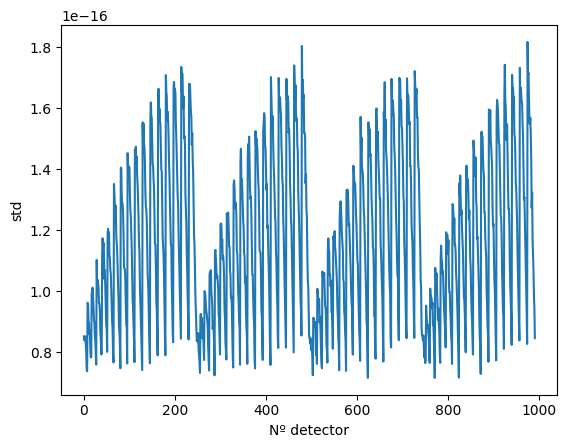

In [12]:
plt.plot(np.std(nn[992:]*np.sqrt(2)/fact, axis=1))
plt.xlabel('Nº detector')
plt.ylabel('std')
plt.show()

In [10]:
# I follow here what's is thone in Qnoise

In [10]:
# is it okay to use this cal file? 

In [12]:
dict_out

{'debug': False,
 'config': 'FI',
 'filter_nu': 220000000000.0,
 'filter_relative_bandwidth': 0.25,
 'beam_shape': 'gaussian',
 'MultiBand': True,
 'nf_sub': 8,
 'center_detector': False,
 'psd': None,
 'bandwidth': None,
 'twosided': None,
 'sigma': None,
 'detector_nep': 4.7e-17,
 'detector_fknee': 0,
 'detector_fslope': 1,
 'detector_ncorr': 10,
 'detector_ngrids': 1,
 'detector_tau': 0.01,
 'polarizer': True,
 'synthbeam_fraction': 1,
 'synthbeam_kmax': 1,
 'synthbeam_peak150_fwhm': 0.39268176,
 'ripples': False,
 'nripples': 0,
 'focal_length': 0.3,
 'optics': 'CalQubic_Optics_v3_CC_FFF.txt',
 'primbeam': 'CalQubic_PrimBeam_v2.fits',
 'detarray': 'CalQubic_DetArray_v4_CC.fits',
 'hornarray': 'CalQubic_HornArray_CC.fits',
 'synthbeam': 'CalQubic_Synthbeam_Analytical_220_FI.fits',
 'nside': 128,
 'kind': 'IQU',
 'absolute': False,
 'temperature': 2.7255,
 'summer': False,
 'RA_center': 0,
 'DEC_center': -57,
 'period': 1,
 'date_obs': '2016-01-01 00:00:00',
 'latitude': -24.18333333

In [14]:
d['config']

'FI'

d["filter_nu"] = int(220) * 1e9
d["nf_sub"] = 12
d["nf_recon"] = 1
_,_,nus,_,_,_ = compute_freq(d["filter_nu"], Nfreq = d["nf_sub"],
relative_bandwidth = 0.25)

In [19]:
nus/1e9

array([194.53700708, 198.65413186, 202.85839027, 207.15162639,
       211.53572332, 216.012604  , 220.58423208, 225.25261278,
       230.01979373, 234.88786591, 239.85896456, 244.9352701 ])

In [9]:
if dict_out['instrument_type'] == 'DB':
    band_used = [150, 220]

instruments = {}
for band in band_used: 
    d = dict_out.copy()
    d['debug'] = True
    d['band'] = band 
    d["filter_nu"] = int(band) * 1e9
    d["nf_sub"] = 1
    d["nf_recon"] = 1

    
    instruments[f"inst_{band}"] = QubicInstrument(d)


filter_nu =  150000000000.0 FRBW =  0.25 dnu =  0.25
primary_shape gaussian
d['primbeam'] CalQubic_PrimBeam_v2.fits
self.synthbeam = /home/belen/Doctorado/qubic-dev/qubic/qubic/calfiles/CalQubic_Synthbeam_Analytical_220_FI.fits
filter_nu =  220000000000.0 FRBW =  0.25 dnu =  0.25
primary_shape gaussian
d['primbeam'] CalQubic_PrimBeam_v2.fits
self.synthbeam = /home/belen/Doctorado/qubic-dev/qubic/qubic/calfiles/CalQubic_Synthbeam_Analytical_220_FI.fits


In [14]:
# el archivo de optics si que cambia. synthbeam no (debería chequear que es) 
# hay algo llamado QubicCalibration

In [15]:
instruments

{'inst_150': Instrument:
     ngrids: 1
     selection: '9-16+17-18+14-22+11-24+10-24+8-28+5-30+4-30+3-32+-544+-32+3-30+4-30+5-28+8-24+10-24+11-22+14-18+17-16+9-'
     synthbeam_fraction: 1
     synthbeam_peak150_fwhm_deg: 0.39268176
     synthbeam_kmax: 1
 
 Calibration:
     path: '/home/belen/Doctorado/qubic-dev/qubic/qubic/calfiles'
     detarray: '/home/belen/Doctorado/qubic-dev/qubic/qubic/calfiles/CalQubic_DetArray_v4_FI.fits'
     hornarray: '/home/belen/Doctorado/qubic-dev/qubic/qubic/calfiles/CalQubic_HornArray_FI.fits'
     optics: '/home/belen/Doctorado/qubic-dev/qubic/qubic/calfiles/CalQubic_Optics_v3_FI_150.txt'
     primbeam: '/home/belen/Doctorado/qubic-dev/qubic/qubic/calfiles/CalQubic_PrimBeam_v2.fits'
     synthbeam: '/home/belen/Doctorado/qubic-dev/qubic/qubic/calfiles/CalQubic_Synthbeam_Analytical_220_FI.fits',
 'inst_220': Instrument:
     ngrids: 1
     selection: '9-16+17-18+14-22+11-24+10-24+8-28+5-30+4-30+3-32+-544+-32+3-30+4-30+5-28+8-24+10-24+11-22+14-18+17-

In [14]:
# en las funciones de get_noise_photon ya esta hecha la realizacion aleatoria. El nep es el que hace 
# de _get_noise_photon_nep

In [14]:
def TOD_noise(inst): 
    pho_noise = inst.get_noise(joint.qubic.sampling, joint.qubic.scene, det_noise=False, photon_noise=True)
    det_noise = inst.get_noise(joint.qubic.sampling, joint.qubic.scene, det_noise=True, photon_noise=False)
    total_noise = inst.get_noise(joint.qubic.sampling, joint.qubic.scene, det_noise=True, photon_noise=True)
    
    return pho_noise, det_noise, total_noise

In [15]:
pho150, det150, total150 = TOD_noise(instruments['inst_150'])
pho220, det220, total220 = TOD_noise(instruments['inst_220'])


FI , central frequency: 150 +- 18 GHz, subband: 150 GHz, n_modes = 1.0
Neutral density filter present, trans =  1.0
CMB , T= 2.7255 K, P = 7.90e-14 W , NEP = 4.04e-18  W/sqrt(Hz)
atm , T= 270.0 K, P = 5.26e-12 W , NEP = 6.10e-17  W/sqrt(Hz)
b'winb1' , T= 290.0 K, P = 4.18e-13 W , NEP = 1.00e-17  W/sqrt(Hz)
b'block1' , T= 290.0 K, P = 4.26e-13 W , NEP = 1.01e-17  W/sqrt(Hz)
b'block2' , T= 290.0 K, P = 4.35e-13 W , NEP = 1.02e-17  W/sqrt(Hz)
b'block3' , T= 45.0 K, P = 6.64e-14 W , NEP = 3.69e-18  W/sqrt(Hz)
b'block4' , T= 45.0 K, P = 6.77e-14 W , NEP = 3.73e-18  W/sqrt(Hz)
b'block5' , T= 45.0 K, P = 6.91e-14 W , NEP = 3.77e-18  W/sqrt(Hz)
b'block6' , T= 5.0 K, P = 3.80e-15 W , NEP = 8.70e-19  W/sqrt(Hz)
b'12cmed' , T= 5.0 K, P = 8.00e-15 W , NEP = 1.26e-18  W/sqrt(Hz)
b'hwp' , T= 5.0 K, P = 1.05e-14 W , NEP = 1.45e-18  W/sqrt(Hz)
b'polgr' , T= 5.0 K, P = 8.50e-15 W , NEP = 1.30e-18  W/sqrt(Hz)
b'ba2ba' , T= 5.0 K, P = 1.88e-13 W , NEP = 5.49e-18  W/sqrt(Hz)
Environment T = 5.0 K, P = 6.2

In [10]:
samp = joint.qubic.sampling.index

In [20]:
%matplotlib inline

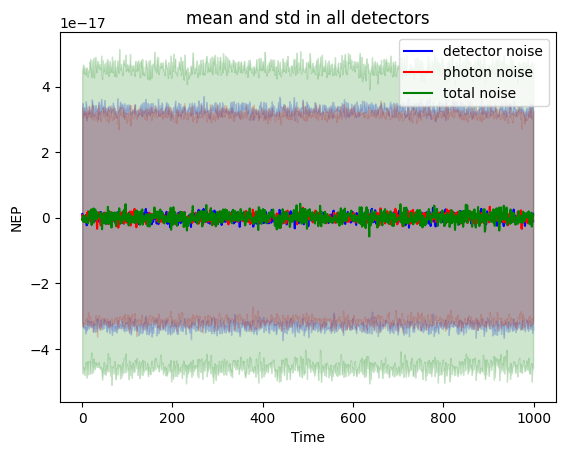

In [28]:
plt.plot(samp, np.mean(det150, axis=0), color='blue', label='detector noise')
plt.fill_between(samp, y1 = np.mean(det150, axis=0) - np.std(det150, axis=0), y2 = np.mean(det150, axis=0) + np.std(det150, axis=0), color='blue', alpha=0.2)

plt.plot(samp, np.mean(pho150, axis=0), color='red', label='photon noise')
plt.fill_between(samp, y1 = np.mean(pho150, axis=0) - np.std(pho150, axis=0), y2 = np.mean(pho150, axis=0) + np.std(pho150, axis=0), color='red', alpha=0.2)

plt.plot(samp, np.mean(total150, axis=0), color='green', label='total noise')
plt.fill_between(samp, y1 = np.mean(total150, axis=0) - np.std(total150, axis=0), y2 = np.mean(total150, axis=0) + np.std(total150, axis=0), color='green',  alpha=0.2)


plt.legend()
plt.title('mean and std in all detectors')
plt.xlabel('Time')
plt.ylabel('NEP')
plt.show()

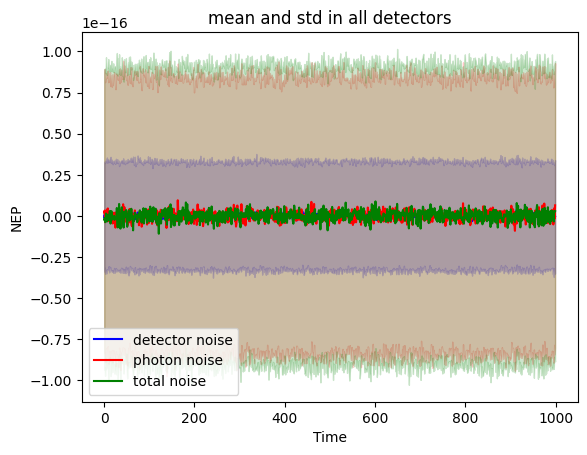

In [30]:
plt.plot(samp, np.mean(det220, axis=0), color='blue', label='detector noise')
plt.fill_between(samp, y1 = np.mean(det220, axis=0) - np.std(det220, axis=0), y2 = np.mean(det220, axis=0) + np.std(det220, axis=0), color='blue', alpha=0.2)

plt.plot(samp, np.mean(pho220, axis=0), color='red', label='photon noise')
plt.fill_between(samp, y1 = np.mean(pho220, axis=0) - np.std(pho220, axis=0), y2 = np.mean(pho220, axis=0) + np.std(pho220, axis=0), color='red', alpha=0.2)

plt.plot(samp, np.mean(total220, axis=0), color='green', label='total noise')
plt.fill_between(samp, y1 = np.mean(total220, axis=0) - np.std(total220, axis=0), y2 = np.mean(total220, axis=0) + np.std(total220, axis=0), color='green',  alpha=0.2)


plt.legend()
plt.title('mean and std in all detectors')
plt.xlabel('Time')
plt.ylabel('NEP')
plt.show()

Text(0.5, 1.0, 'Histogram of NEP values in each detector')

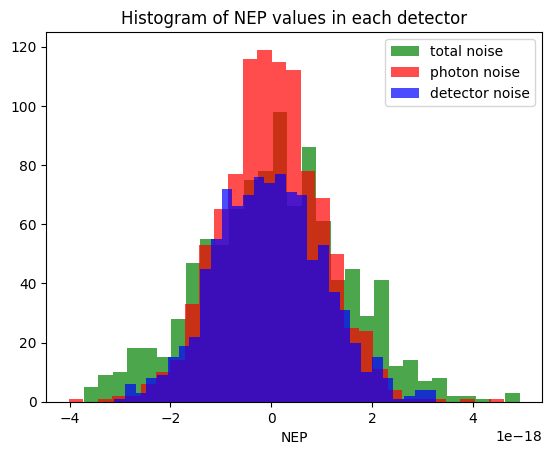

In [31]:
plt.hist(np.mean(total150, axis=1), bins=30, color='green', alpha = 0.7, label='total noise' )
plt.hist(np.mean(pho150, axis=1), bins=30, color='red', alpha = 0.7, label='photon noise')
plt.hist(np.mean(det150, axis=1), bins=30, color='blue', alpha = 0.7, label='detector noise' )
plt.xlabel('NEP')
plt.legend()
plt.title('Histogram of NEP values in each detector')

Text(0.5, 1.0, 'Histogram of NEP values in each detector')

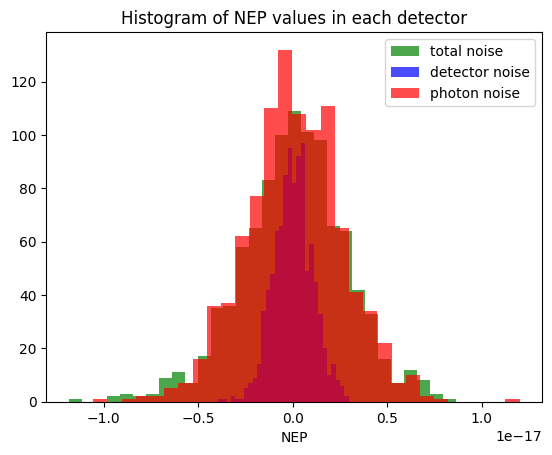

In [33]:
plt.hist(np.mean(total220, axis=1), bins=30, color='green', alpha = 0.7, label='total noise' )
plt.hist(np.mean(det220, axis=1), bins=30, color='blue', alpha = 0.7, label='detector noise' )
plt.hist(np.mean(pho220, axis=1), bins=30, color='red', alpha = 0.7, label='photon noise')

plt.xlabel('NEP')
plt.legend()
plt.title('Histogram of NEP values in each detector')

In [40]:
from scipy.stats import norm

In [46]:
muTot_150, stdTot_150 = norm.fit(np.mean(total150, axis = 1))
muDet_150, stdDet_150 = norm.fit(np.mean(det150, axis = 1))
muPhot_150, stdPhot_150 = norm.fit(np.mean(pho150, axis = 1))

In [48]:
muTot_220, stdTot_220 = norm.fit(np.mean(total220, axis = 1))
muDet_220, stdDet_220 = norm.fit(np.mean(det220, axis = 1))
muPhot_220, stdPhot_220 = norm.fit(np.mean(pho220, axis = 1))

In [49]:
muTot_220

7.386567413394797e-20

In [61]:
muTot_150

6.249130623971077e-20

In [51]:
stdTot_150

1.433234332107018e-18

In [52]:
stdTot_220

2.8093606340845195e-18

In [53]:
stdPhot_220

2.589929458016303e-18

In [54]:
stdPhot_150

9.973509818707831e-19

In [11]:
inst150 = instruments['inst_150']
inst220 = instruments['inst_220']

In [39]:
# estos son los NEP totales, con estos tengo que comparar la std del noise TOD, pero ver ese factor
# que se agrega en Qacquiation

In [17]:
np.shape(nep_photon150)

(992,)

In [19]:
nep_photon150 = inst150._get_noise_photon_nep(joint.qubic.scene)
nep_photon220 = inst220._get_noise_photon_nep(joint.qubic.scene)


FI , central frequency: 150 +- 18 GHz, subband: 150 GHz, n_modes = 1.0
Neutral density filter present, trans =  1.0
CMB , T= 2.7255 K, P = 7.90e-14 W , NEP = 4.04e-18  W/sqrt(Hz)
atm , T= 270.0 K, P = 5.26e-12 W , NEP = 6.10e-17  W/sqrt(Hz)
b'winb1' , T= 290.0 K, P = 4.18e-13 W , NEP = 1.00e-17  W/sqrt(Hz)
b'block1' , T= 290.0 K, P = 4.26e-13 W , NEP = 1.01e-17  W/sqrt(Hz)
b'block2' , T= 290.0 K, P = 4.35e-13 W , NEP = 1.02e-17  W/sqrt(Hz)
b'block3' , T= 45.0 K, P = 6.64e-14 W , NEP = 3.69e-18  W/sqrt(Hz)
b'block4' , T= 45.0 K, P = 6.77e-14 W , NEP = 3.73e-18  W/sqrt(Hz)
b'block5' , T= 45.0 K, P = 6.91e-14 W , NEP = 3.77e-18  W/sqrt(Hz)
b'block6' , T= 5.0 K, P = 3.80e-15 W , NEP = 8.70e-19  W/sqrt(Hz)
b'12cmed' , T= 5.0 K, P = 8.00e-15 W , NEP = 1.26e-18  W/sqrt(Hz)
b'hwp' , T= 5.0 K, P = 1.05e-14 W , NEP = 1.45e-18  W/sqrt(Hz)
b'polgr' , T= 5.0 K, P = 8.50e-15 W , NEP = 1.30e-18  W/sqrt(Hz)
b'ba2ba' , T= 5.0 K, P = 1.88e-13 W , NEP = 5.49e-18  W/sqrt(Hz)
Environment T = 5.0 K, P = 6.2

In [23]:
np.shape(nep_photon150) # NEP por detector

(992,)

In [22]:
np.shape(inst150.detector.center.T[0])

(992,)

In [26]:
np.max(nep_photon150)

6.522215916355245e-17

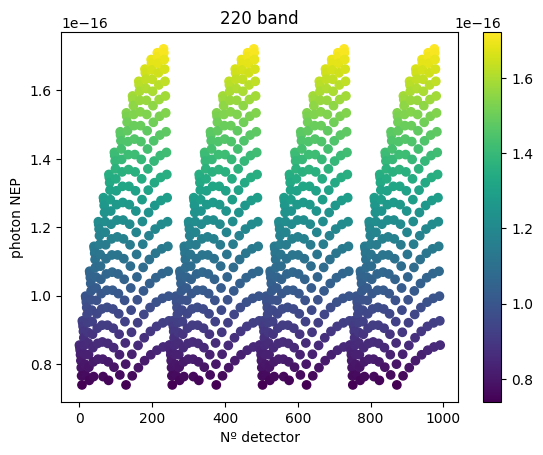

In [24]:
plt.scatter(np.arange(len(nep_photon220)), nep_photon220, c= nep_photon220 )
plt.xlabel('Nº detector')
plt.ylabel('photon NEP')
plt.colorbar()
plt.title('220 band')
plt.show()

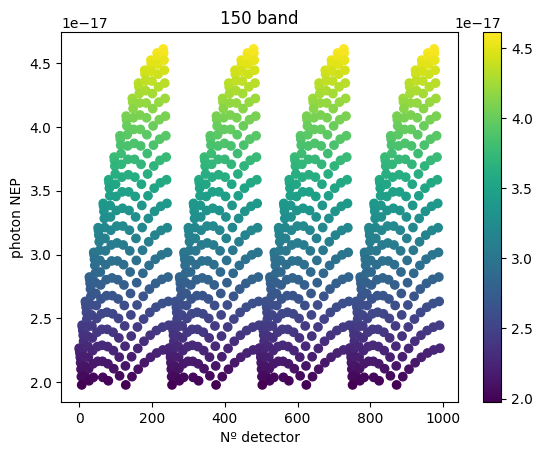

In [46]:
plt.scatter(np.arange(len(nep_photon150)), nep_photon150/np.sqrt(2), c= nep_photon150/np.sqrt(2) )
plt.xlabel('Nº detector')
plt.ylabel('photon NEP')
plt.title('150 band')
plt.colorbar()
plt.show()

Text(0.5, 0, 'Nº detector')

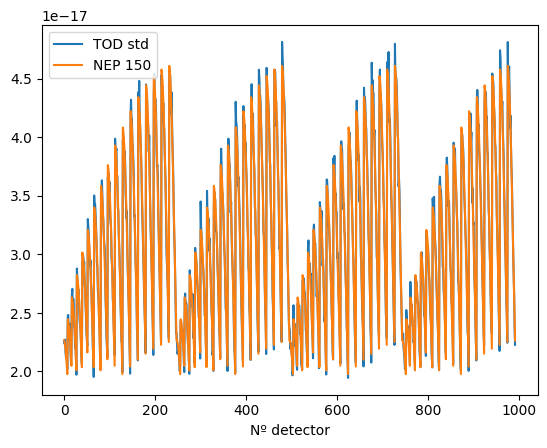

In [21]:
plt.plot((np.std(nn[:992], axis=1)/fact), label='TOD std')
plt.plot(nep_photon150/np.sqrt(2.0), label='NEP 150')
plt.legend()
plt.xlabel('Nº detector')

Text(0.5, 0, 'Nº detector')

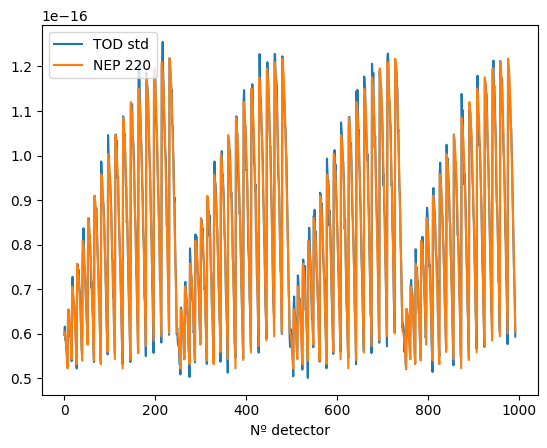

In [21]:
plt.plot((np.std(nn[992:], axis=1)/fact), label='TOD std')
plt.plot(nep_photon220/np.sqrt(2.0), label='NEP 220')
plt.legend()
plt.xlabel('Nº detector')

In [25]:
ratio_220 = (np.std(nn[992:]*np.sqrt(2.0)/fact, axis=1))/nep_photon220

In [26]:
ratio_150 = (np.std(nn[:992]*np.sqrt(2.0)/fact, axis=1))/nep_photon150

In [32]:
np.mean(ratio_220)

0.8153652544836688

In [34]:
sampling.period

1.0

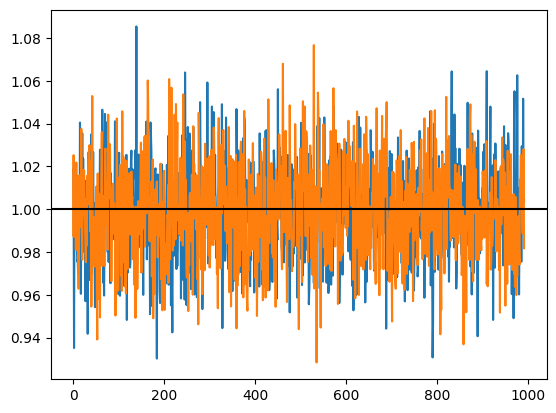

In [28]:
plt.plot(ratio_150, label='ratio 150')
plt.plot(ratio_220, label='ratio 220')
plt.axhline(y=1, color='black')

In [20]:
noisepar_150 = inst150.load_NEP_parameters(joint.qubic.scene)

FI , central frequency: 150 +- 18 GHz, subband: 150 GHz, n_modes = 1.0
Neutral density filter present, trans =  1.0


In [21]:
noisepar_220 = inst220.load_NEP_parameters(joint.qubic.scene)

FI , central frequency: 220 +- 27 GHz, subband: 220 GHz, n_modes = 4.714155461361596
Neutral density filter present, trans =  1.0


In [26]:
noisepar_150.names

['CMB',
 'atm',
 b'winb1',
 b'block1',
 b'block2',
 b'block3',
 b'block4',
 b'block5',
 b'block6',
 b'12cmed',
 b'hwp',
 b'polgr',
 b'ba2ba',
 b'combin',
 b'cslpe',
 b'dichro',
 b'ndf',
 b'7cmlpe',
 b'6.2cmlpe',
 b'5.6cmlpe']

In [27]:
noisepar_220.names

['CMB',
 'atm',
 b'winb1',
 b'block1',
 b'block2',
 b'block3',
 b'block4',
 b'block5',
 b'block6',
 b'12cmed',
 b'hwp',
 b'polgr',
 b'ba2ba',
 b'combin',
 b'cslpe',
 b'dichro',
 b'ndf',
 b'9cmlpe',
 b'11cmlpe',
 b'bdf']

In [44]:
# components per band 

# 1. NEP before horns array 


# 150: 
# 2. NEP horns
# 3. NEP environment 
# 4. NEP combiner 
# 5. NEP coldspot 
# 6. neutral density (no se bien) 
# 7. lowpassedge (2)

# 220: 
# 2. NEP horns
# 3. NEP env
# 4. NEP combiner 
# 5. NEP coldspot 
# 6. NEP dichroic
# 7. NEP lfiter 220 (3)

# 8. NEP last_filter


In [49]:
noisepar_220.indf

16

In [28]:
sampling = joint.qubic.sampling


In [22]:
def load_NEP_components(inst, noisepar, band_150 = True):
    dict_before_horns = inst.NEP_before_horns(noisepar, noisepar.nu, return_only=True, sampling=sampling) # se reescriben los 12 primeros NEP para cada detector
    
    dict_horns = inst.NEP_horns(noisepar, return_only=True, sampling=sampling)
    dict_env = inst.NEP_environment(noisepar, noisepar.names, return_only=True, sampling=sampling)
    dict_combiner = inst.NEP_combiner(noisepar, return_only=True, sampling=sampling)
    dict_coldspot = inst.NEP_coldstop(noisepar, return_only=True, sampling=sampling)
    dict_dich = inst.NEP_dichroic(noisepar, return_only=True, sampling=sampling)

    
    if band_150:
        dict_ndf = inst.NEP_neutraldensityfilter(noisepar, return_only=True, sampling=sampling)
        dict_lpe1 = inst.NEP_lowpassedge(noisepar, noisepar.lpe1, return_only=True, sampling=sampling)
        dict_lpe2 = inst.NEP_lowpassedge(noisepar, noisepar.lpe2, return_only=True, sampling=sampling)
    else: 
        dict_ndf = inst.NEP_lpefilter_220(noisepar, noisepar.indf, return_only=True, sampling=sampling)
        dict_lpe1 = inst.NEP_lpefilter_220(noisepar, noisepar.lpe1, return_only=True, sampling=sampling)
        dict_lpe2 = inst.NEP_lpefilter_220(noisepar, noisepar.lpe2, return_only=True, sampling=sampling)        
        
    dict_last = inst.NEP_lastfilter(noisepar, return_only=True, sampling=sampling)
    
    allnoisearray = [dict_before_horns, dict_horns, dict_combiner, dict_coldspot, dict_dich, dict_ndf, dict_lpe1, dict_lpe2, dict_last]
    
    return allnoisearray

In [74]:
# el last filter es el mismo para las dos bandas

In [23]:
allnoise_150 = load_NEP_components(inst150, noisepar_150, band_150=True)

CMB , T= 2.7255 K, P = 7.90e-14 W , NEP = 4.04e-18  W/sqrt(Hz)
atm , T= 270.0 K, P = 5.26e-12 W , NEP = 6.10e-17  W/sqrt(Hz)
b'winb1' , T= 290.0 K, P = 4.18e-13 W , NEP = 1.00e-17  W/sqrt(Hz)
b'block1' , T= 290.0 K, P = 4.26e-13 W , NEP = 1.01e-17  W/sqrt(Hz)
b'block2' , T= 290.0 K, P = 4.35e-13 W , NEP = 1.02e-17  W/sqrt(Hz)
b'block3' , T= 45.0 K, P = 6.64e-14 W , NEP = 3.69e-18  W/sqrt(Hz)
b'block4' , T= 45.0 K, P = 6.77e-14 W , NEP = 3.73e-18  W/sqrt(Hz)
b'block5' , T= 45.0 K, P = 6.91e-14 W , NEP = 3.77e-18  W/sqrt(Hz)
b'block6' , T= 5.0 K, P = 3.80e-15 W , NEP = 8.70e-19  W/sqrt(Hz)
b'12cmed' , T= 5.0 K, P = 8.00e-15 W , NEP = 1.26e-18  W/sqrt(Hz)
b'hwp' , T= 5.0 K, P = 1.05e-14 W , NEP = 1.45e-18  W/sqrt(Hz)
b'polgr' , T= 5.0 K, P = 8.50e-15 W , NEP = 1.30e-18  W/sqrt(Hz)
b'ba2ba' , T= 5.0 K, P = 1.88e-13 W , NEP = 5.49e-18  W/sqrt(Hz)
Environment T = 5.0 K, P = 6.25e-13 W , NEP = 1.16e-17  W/sqrt(Hz)
b'combin' , T= 1.0 K, P = 5.37e-16 W , NEP = 2.31e-19  W/sqrt(Hz)
b'cslpe' , T=

In [24]:
allnoise_220 = load_NEP_components(inst220, noisepar_220, band_150=False)

CMB , T= 2.7255 K, P = 2.02e-13 W , NEP = 7.72e-18  W/sqrt(Hz)
atm , T= 270.0 K, P = 3.30e-11 W , NEP = 1.62e-16  W/sqrt(Hz)
b'winb1' , T= 290.0 K, P = 2.62e-12 W , NEP = 2.95e-17  W/sqrt(Hz)
b'block1' , T= 290.0 K, P = 2.67e-12 W , NEP = 2.98e-17  W/sqrt(Hz)
b'block2' , T= 290.0 K, P = 2.73e-12 W , NEP = 3.02e-17  W/sqrt(Hz)
b'block3' , T= 45.0 K, P = 4.03e-13 W , NEP = 1.10e-17  W/sqrt(Hz)
b'block4' , T= 45.0 K, P = 4.11e-13 W , NEP = 1.11e-17  W/sqrt(Hz)
b'block5' , T= 45.0 K, P = 4.19e-13 W , NEP = 1.12e-17  W/sqrt(Hz)
b'block6' , T= 5.0 K, P = 1.56e-14 W , NEP = 2.13e-18  W/sqrt(Hz)
b'12cmed' , T= 5.0 K, P = 3.28e-14 W , NEP = 3.10e-18  W/sqrt(Hz)
b'hwp' , T= 5.0 K, P = 4.32e-14 W , NEP = 3.55e-18  W/sqrt(Hz)
b'polgr' , T= 5.0 K, P = 3.49e-14 W , NEP = 3.19e-18  W/sqrt(Hz)
b'ba2ba' , T= 5.0 K, P = 1.76e-13 W , NEP = 7.18e-18  W/sqrt(Hz)
Shape of NEP_phot2_env_nobunch =  (992,)
Shape of NEP_phot2_env_nobunch =  (992,)
ib2b 12
Value used in current version of qubicsoft 4.59643690801

In [25]:
dict_before_horns = allnoise_150[0]
ncomp_before_horns = len(dict_before_horns["power"])
ncomp_after_horns = len(allnoise_150[1:])

In [26]:
np.shape(dict_before_horns["power"])

(12, 992)

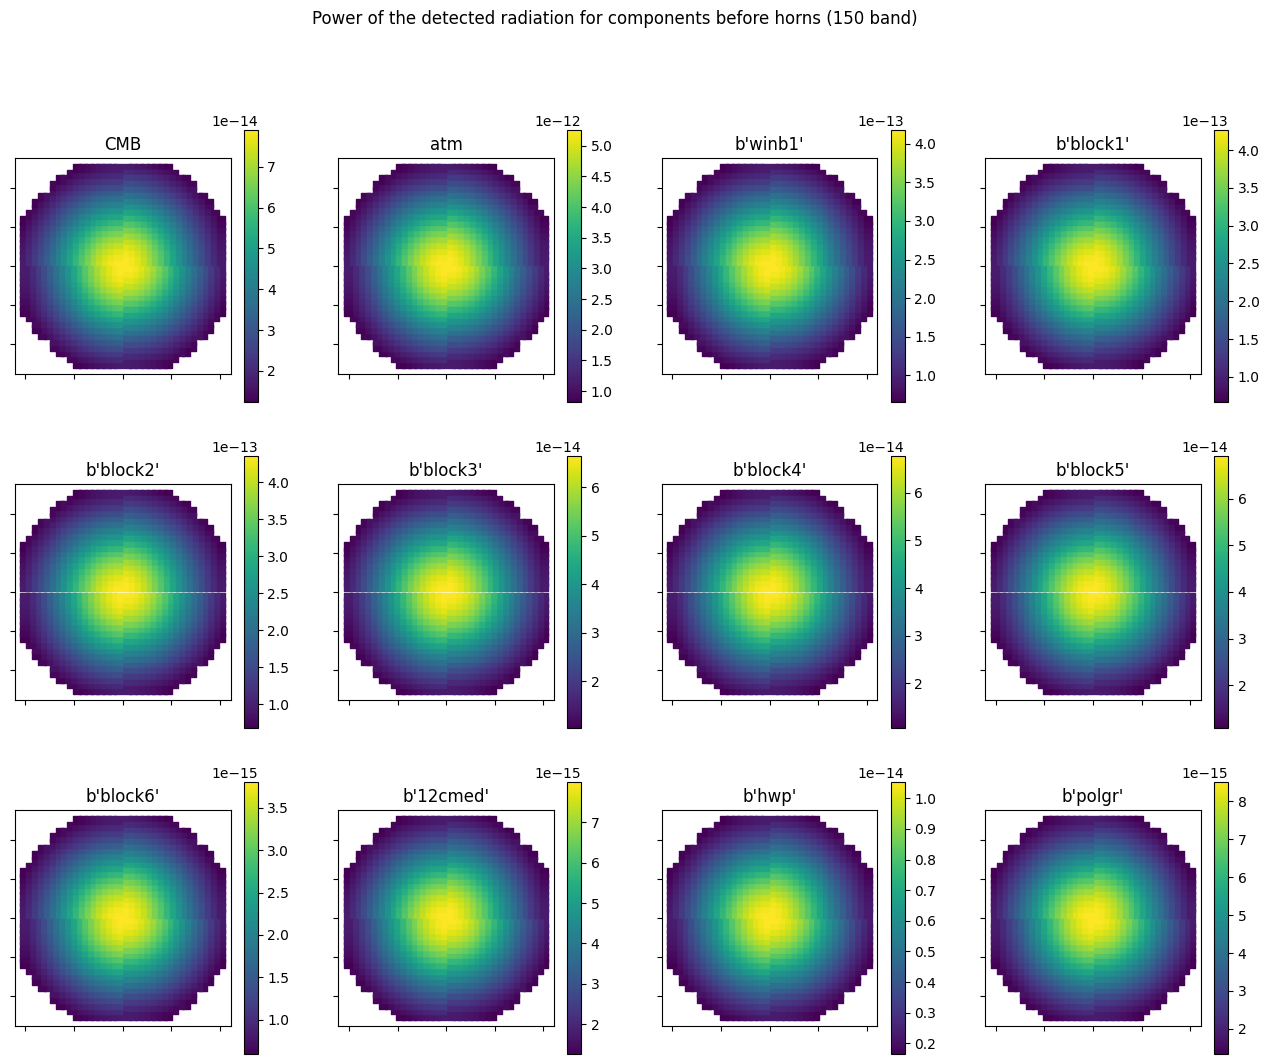

In [28]:
fig2, ax2 = plt.subplots(nrows = 3, ncols = 4, figsize = (16,12))
fig2.suptitle('Power of the detected radiation for components before horns (150 band)')
ax2 = ax2.ravel()
for j in range(ncomp_before_horns):
    ax2[j].cla()
    plt.axes(ax2[j])
    ax2[j].set_title("{}".format(noisepar_150.names[j]))
    cp = ax2[j].scatter(inst150.detector.center.T[0],
                        inst150.detector.center.T[1],
                        c = allnoise_150[0]['power'][j], marker = 's')
    cbar = fig2.colorbar(cp,)
    ax2[j].set_xticklabels("")
    ax2[j].set_yticklabels("")
    ax2[j].set_aspect('equal')
    
#plt.show()

plt.savefig('phonoise_focalplane_before150.png')

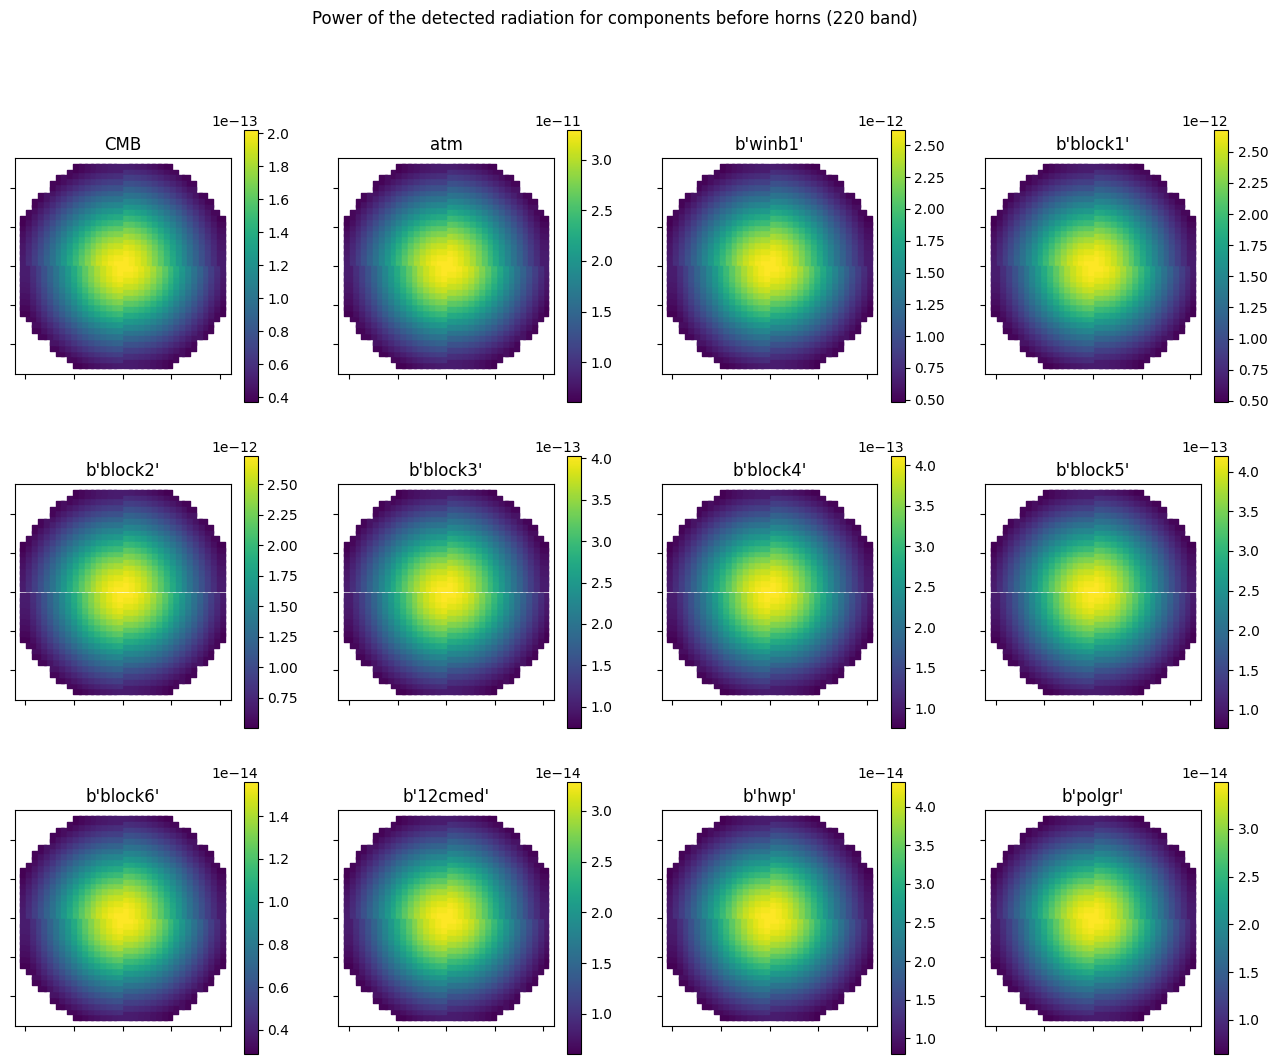

In [29]:
fig2, ax2 = plt.subplots(nrows = 3, ncols = 4, figsize = (16,12))
fig2.suptitle('Power of the detected radiation for components before horns (220 band)')
ax2 = ax2.ravel()
for j in range(ncomp_before_horns):
    ax2[j].cla()
    plt.axes(ax2[j])
    ax2[j].set_title("{}".format(noisepar_220.names[j]))
    cp = ax2[j].scatter(inst220.detector.center.T[0],
                        inst220.detector.center.T[1],
                        c = allnoise_220[0]['power'][j], marker = 's')
    cbar = fig2.colorbar(cp,)
    ax2[j].set_xticklabels("")
    ax2[j].set_yticklabels("")
    ax2[j].set_aspect('equal')
    
#plt.show()
plt.savefig('phonoise_focalplane_before220.png')

In [33]:
np.shape(allnoise_150)

(9,)

In [64]:
noisepar_150.names[7+ncomp_before_horns]

b'5.6cmlpe'

In [62]:
allnoise_150[8]['power'].max()

9.925020786433802e-17

In [65]:
np.mean(allnoise_150[8]['power'])

9.925020786433797e-17

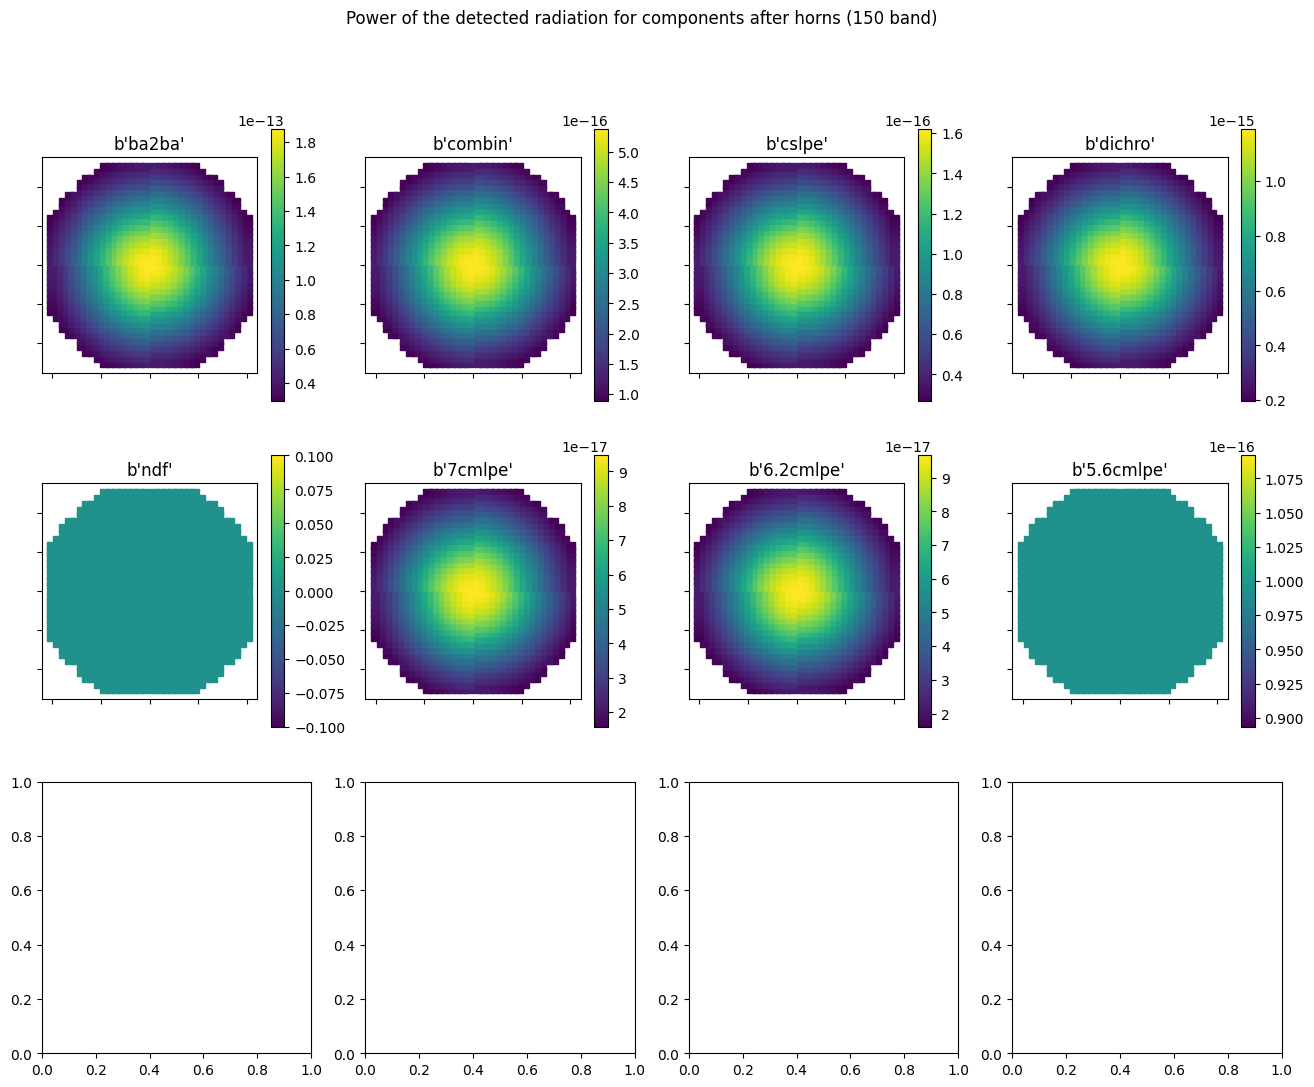

In [30]:
fig2, ax2 = plt.subplots(nrows = 3, ncols = 4, figsize = (16,12))
fig2.suptitle('Power of the detected radiation for components after horns (150 band)')
ax2 = ax2.ravel()
for j in range(0, ncomp_after_horns):
    ax2[j].cla()
    plt.axes(ax2[j])
    ax2[j].set_title("{}".format(noisepar_150.names[j+ncomp_before_horns]))
    cp = ax2[j].scatter(inst150.detector.center.T[0],
                        inst150.detector.center.T[1],
                        c = allnoise_150[j+1]['power'], marker = 's')
    cbar = fig2.colorbar(cp,)
    ax2[j].set_xticklabels("")
    ax2[j].set_yticklabels("")
    ax2[j].set_aspect('equal')

plt.savefig('phonoise_focalplane_after150.png')
#plt.show()

In [69]:
noisepar_220.names

['CMB',
 'atm',
 b'winb1',
 b'block1',
 b'block2',
 b'block3',
 b'block4',
 b'block5',
 b'block6',
 b'12cmed',
 b'hwp',
 b'polgr',
 b'ba2ba',
 b'combin',
 b'cslpe',
 b'dichro',
 b'ndf',
 b'9cmlpe',
 b'11cmlpe',
 b'bdf']

In [72]:
allnoise_220[2]

{'power': array([6.98204959e-18, 6.98204959e-18, 6.98204959e-18, 6.98204959e-18,
        6.98204959e-18, 6.98204959e-18, 6.98204959e-18, 6.98204959e-18,
        6.98204959e-18, 6.98204959e-18, 6.98204959e-18, 6.98204959e-18,
        6.98204959e-18, 6.98204959e-18, 6.98204959e-18, 6.98204959e-18,
        6.98204959e-18, 6.98204959e-18, 6.98204959e-18, 6.98204959e-18,
        6.98204959e-18, 6.98204959e-18, 6.98204959e-18, 6.98204959e-18,
        6.98204959e-18, 6.98204959e-18, 6.98204959e-18, 6.98204959e-18,
        6.98204959e-18, 6.98204959e-18, 6.98204959e-18, 6.98204959e-18,
        6.98204959e-18, 6.98204959e-18, 6.98204959e-18, 6.98204959e-18,
        6.98204959e-18, 6.98204959e-18, 6.98204959e-18, 6.98204959e-18,
        6.98204959e-18, 6.98204959e-18, 6.98204959e-18, 6.98204959e-18,
        6.98204959e-18, 6.98204959e-18, 6.98204959e-18, 6.98204959e-18,
        6.98204959e-18, 6.98204959e-18, 6.98204959e-18, 6.98204959e-18,
        6.98204959e-18, 6.98204959e-18, 6.98204959e-18,

In [73]:
# ver expresiones de por qué dan un valor constante para todos los detectores

In [77]:
np.shape(noisepar_150.transmissions)

(20,)

In [79]:
noisepar_150.tr_prod

array([0.62597688, 0.62597688, 0.63875192, 0.65178767, 0.66508946,
       0.70009417, 0.7143818 , 0.72896102, 0.74383778, 0.78298714,
       0.82419698, 0.83252221, 0.84093152, 0.84942578, 0.8941324 ,
       0.941192  , 0.941192  , 0.9604    , 0.98      , 1.        ])

In [32]:
allnoise_220

[{'power': array([[4.98868996e-14, 4.92583347e-14, 4.81660976e-14, ...,
          6.79851067e-14, 5.85046095e-14, 4.98868996e-14],
         [8.13603784e-12, 8.03352540e-12, 7.85539280e-12, ...,
          1.10876684e-11, 9.54149726e-12, 8.13603784e-12],
         [6.47040312e-13, 6.38887734e-13, 6.24721260e-13, ...,
          8.81776679e-13, 7.58813257e-13, 6.47040312e-13],
         ...,
         [8.09943445e-15, 7.99738320e-15, 7.82005201e-15, ...,
          1.10377859e-14, 9.49857082e-15, 8.09943445e-15],
         [1.06571506e-14, 1.05228726e-14, 1.02895421e-14, ...,
          1.45234024e-14, 1.24981195e-14, 1.06571506e-14],
         [8.61183886e-15, 8.50333142e-15, 8.31478151e-15, ...,
          1.17360828e-14, 1.00994905e-14, 8.61183886e-15]]),
  'NEP_phot2_nobunch': array([[1.45443802e-35, 1.43611240e-35, 1.40426854e-35, ...,
          1.98208598e-35, 1.70568484e-35, 1.45443802e-35],
         [2.37203813e-33, 2.34215092e-33, 2.29021689e-33, ...,
          3.23257742e-33, 2.78179573e

In [70]:
noisepar_220.names[1+ncomp_before_horns]

b'combin'

In [73]:
allnoise_220[2]['power'].max()

6.982049588470897e-18

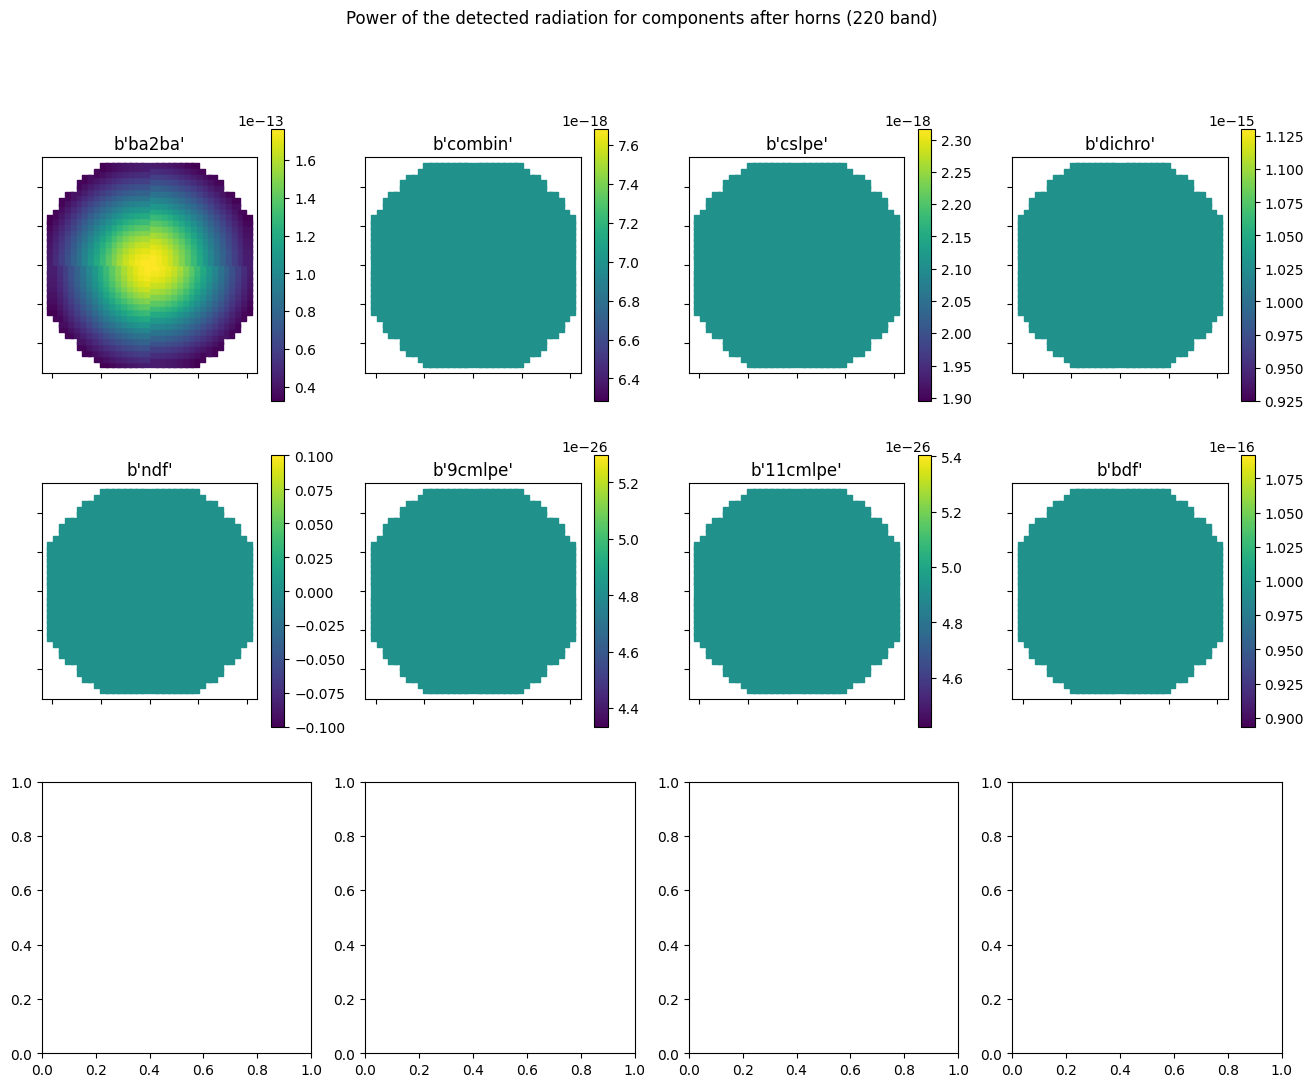

In [31]:
fig2, ax2 = plt.subplots(nrows = 3, ncols = 4, figsize = (16,12))
fig2.suptitle('Power of the detected radiation for components after horns (220 band)')
ax2 = ax2.ravel()
for j in range(0, ncomp_after_horns):
    ax2[j].cla()
    plt.axes(ax2[j])
    ax2[j].set_title("{}".format(noisepar_220.names[j+ncomp_before_horns]))
    cp = ax2[j].scatter(inst220.detector.center.T[0],
                        inst220.detector.center.T[1],
                        c = allnoise_220[j+1]['power'], marker = 's')
    cbar = fig2.colorbar(cp,)
    ax2[j].set_xticklabels("")
    ax2[j].set_yticklabels("")
    ax2[j].set_aspect('equal')

plt.savefig('phonoise_focalplane_after220.png')

#plt.show()